## Using TensorFlow in Machine Learning: simple example
One of the most common uses of TensorFlow is building and training machine learning models.

Let’s create a simple neural network model using TensorFlow's high-level API, Keras.

We'll build a simple model to predict y value for a given x value. I created CSV file where
- physics score: denotes score obtained in physics
- hours studied : denotes how many hours studied

- This actually follows a simple relationship: score = 1 + 2*hours .  ( That is  y = 1 + 2x )


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.18.0
NumPy: 1.26.4


**Data collection**

Here we collect data

In [3]:
# Load data from CSV

df = pd.DataFrame({
    'hour': [1, 2, 3, 4],
    'score':[3, 5, 7, 9] 
})

# df = pd.read_csv("physics_score_hours.csv")  # Replace with your actual CSV file path
# df = pd.read_csv("/content/sample_data/physics_score_hours.csv")  # Replace with your actual CSV file path

print(df)

   hour  score
0     1      3
1     2      5
2     3      7
3     4      9


In [5]:
print(df.shape)

(4, 2)


**EDA:**
Lets try our visualize our data

In [4]:
X = df[['hour']].values.astype(np.float32)  # Extract 'x' column as NumPy array
y = df[['score']].values.astype(np.float32)  # Extract 'y' column as NumPy array

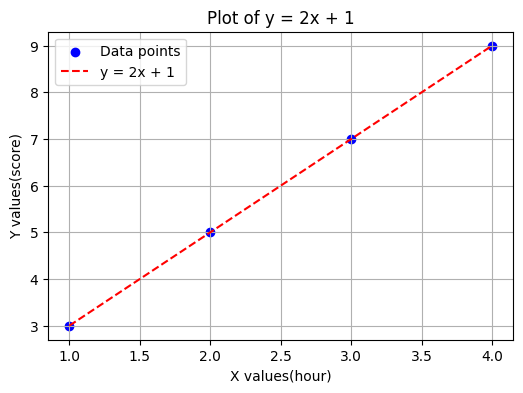

In [5]:
# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='Data points')  # Scatter plot for points
plt.plot(X, 2*X + 1, color='red', linestyle='--', label='y = 2x + 1')  # Line

# Labels and Title
plt.xlabel('X values(hour)')
plt.ylabel('Y values(score)')
plt.title('Plot of y = 2x + 1')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

**Build model**
 This is neural network with single neuron as input.


In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Dense(units=1, input_shape=(1,))  # Single neuron, single input
])

print(model.summary())

# None means batch size can be anything

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Compile the model
model.compile(optimizer='sgd', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=20, verbose=1, validation_split=0.2)

# Lets see the neuron

In [8]:
# May have to: !pip install graphviz pydot
# !pip install pydot

# Restart the kernel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


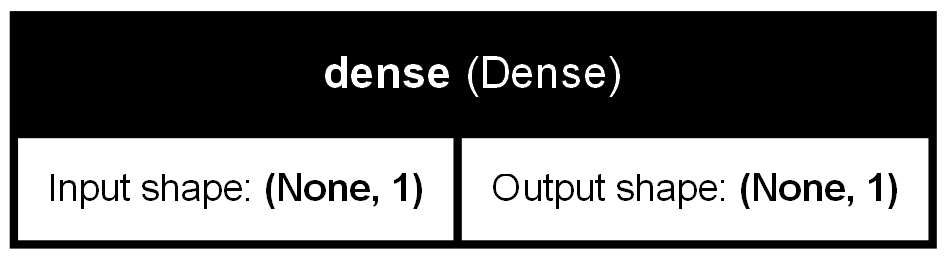

In [8]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

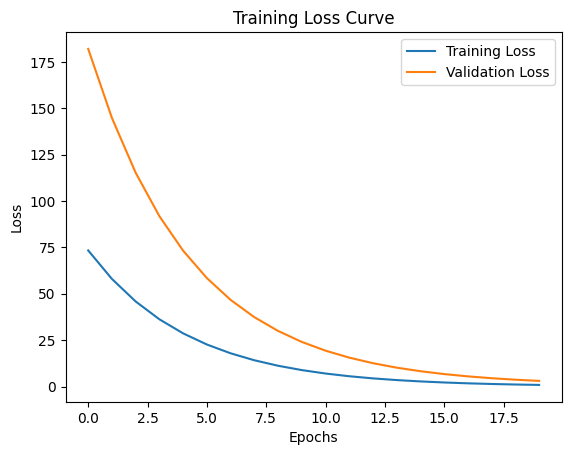

In [9]:
# Plot the loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()


This process took 3 minutes on CPU for 500 epochs

In [10]:
# Lets make a prediction on 1 data and compare with actual value
x_test =  np.array([2], dtype=np.float32).reshape(-1, 1)
y_predict = model.predict(x_test)

print(f'predicted value:{y_predict}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
predicted value:[[4.279887]]


In [11]:
# predict on range of values
# x_test = np.array([[1], [1.5], [2.5], [3.5], [5], [6]], dtype=np.float32) # this works too.
x_test =  np.array([1, 1.5, 2, 2.5, 3, 3.5, 5, 6], dtype=np.float32).reshape(-1, 1)
y_predict = model.predict(x_test)

# Compute actual y values based on equation y = 2*x + 1
y_actual = 1 + 2 * x_test

# Print predictions and actual values
# print("Predictions vs Actual Values:")
# for i in range(len(x_test)):
#     print(f"x = {x_test[i][0]:.1f} | Predicted y = {y_predict[i][0]:.2f} | Actual y = {y_actual[i][0]:.2f}")
print("**************************")

# Or Create a DataFrame to store results
df_results = pd.DataFrame({
    'X'          : x_test.flatten(),
    'Predicted Y': y_predict.flatten(),
    'Actual Y'   : y_actual.flatten()
})

# Print DataFrame
print(df_results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
**************************
     X  Predicted Y  Actual Y
0  1.0     2.791422       3.0
1  1.5     3.535655       4.0
2  2.0     4.279887       5.0
3  2.5     5.024119       6.0
4  3.0     5.768352       7.0
5  3.5     6.512585       8.0
6  5.0     8.745281      11.0
7  6.0    10.233747      13.0


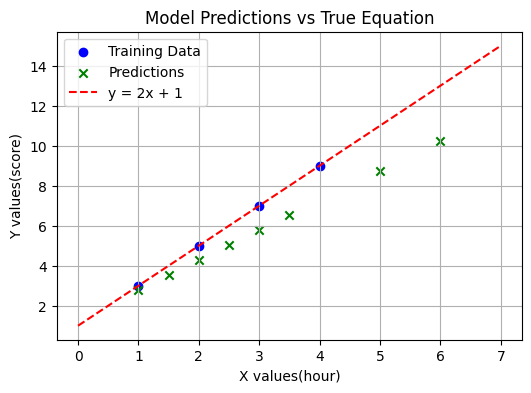

In [12]:
# Plotting
plt.figure(figsize=(6, 4))

# Scatter plot of true data
plt.scatter(X, y, color='blue', label='Training Data')

# Scatter plot of predictions
plt.scatter(x_test, y_predict, color='green', marker='x', label='Predictions')

# True equation line
x_line = np.linspace(0, 7, 100).reshape(-1, 1)  # Smoother line
y_line = 1 + 2 * x_line
plt.plot(x_line, y_line, color='red', linestyle='--', label='y = 2x + 1')

# Labels and legend
plt.xlabel('X values(hour)')
plt.ylabel('Y values(score)')
plt.title('Model Predictions vs True Equation')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


### Great
So we have created simple NN that has learned from data(x,y), and was able to make pretty accurate predictions on test dataset.

In [13]:
# # Evaluate the model on test data
x_test = np.array([1, 1.5, 2.5, 3.5, 5, 6], dtype=np.float32).reshape(-1, 1)
y_test = 2 * x_test + 1  # True values based on y = 2x + 1

# Evaluate the model (returns only loss, since accuracy is not relevant for regression)
test_loss = model.evaluate(x_test, y_test, verbose=0)

# Calculate baseline MSE (predicting the mean of y_test)
y_mean = np.mean(y_test)
baseline_mse = np.mean((y_test - y_mean) ** 2)

print(f"Model MSE: {test_loss:.4f}")
print(f"Baseline MSE: {baseline_mse:.4f}")

# Check if the model performs better than the baseline
if test_loss < baseline_mse:
    print("The model performs better than the baseline.")
else:
    print("The model is not better than a simple mean predictor.")


Model MSE: 2.6933
Baseline MSE: 12.9167
The model performs better than the baseline.


Tensorflow does not provide its own R-square values, so lets use scikit-learn to calculate R-square.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict values
y_pred = model.predict(x_test)

# Compute errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Mean Absolute Error (MAE): 1.3595
Mean Squared Error (MSE): 2.6933
R² Score: 0.7915


R-square is looking good. So lets save the model

In [15]:
model.save("model.keras")

In [16]:
# Load the model back if you need in future

loaded_model = tf.keras.models.load_model("model.keras")

In [17]:
# Predict the score of 2 students based on hours studied: 1 hr, 1.5hr
x_test = np.array([1, 1.5], dtype=np.float32).reshape(-1, 1)
y_predict = loaded_model.predict(x_test)
print(y_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[[2.7914224]
 [3.5356548]]


## TODO
Add another column 'activity' in seperate CSV file, where activity would refer to the amount of time spent each day on physical play activity.
Here use score =  1 + 2 * hour + .5 * activity ( y = 1 + 2 * x1 + .5 * x2).

Then use above model to make predictions. Do this in seperate notebook and follow exactly same steps as this one.